In [1]:
#Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.float_format", "{:.4f}".format)
DATA_DIR = "../data"

In [2]:
#Load data
combined = pd.read_csv(
    os.path.join(DATA_DIR, "combined.csv"),
    parse_dates=["HourDK"]
).sort_values("HourDK").reset_index(drop=True)

# We work with differenced series throughout this notebook
# because Granger causality assumes stationarity
diff_cols = [
    "SpotPriceEUR_diff",
    "TotalWind_diff",
    "OffshoreWind_diff",
    "OnshoreWind_diff",
    "Solar_diff"
]

data = combined[["HourDK"] + diff_cols].dropna().reset_index(drop=True)

print(f"Rows: {len(data)}")
data.head()

Rows: 2159


,HourDK,SpotPriceEUR_diff,TotalWind_diff,OffshoreWind_diff,OnshoreWind_diff,Solar_diff
0,2025-07-02 01:00:00,-16.5900,74.7066,69.6704,5.0363,-0.1031
1,2025-07-02 02:00:00,-10.1600,82.5954,37.0222,45.5732,-0.0324
2,2025-07-02 03:00:00,-0.4600,-72.0940,-109.5769,37.4829,0.1761
3,2025-07-02 04:00:00,-0.3700,-256.7372,-142.7922,-113.9450,2.3491
4,2025-07-02 05:00:00,8.8400,35.4470,69.1637,-33.7167,48.2632


X is said to "Granger cause" Y if past values of X contain
information that helps predict Y, beyond what past values of
Y alone can tell us.

Important limitations:
  1. Granger causality is PREDICTIVE, not mechanistic.
     It tells us X is a useful predictor of Y — not that X
     physically causes Y.
  2. A confounding variable Z could drive both X and Y,
     producing Granger causality with no true causal link.
  3. Results are sensitive to lag selection and stationarity.

With those caveats stated, Granger causality is still one of
the most rigorous tools available for time series causal inference.

In [3]:
#Granger causaity helper
def granger_report(data: pd.DataFrame, cause: str, effect: str, max_lags: int = 24) -> pd.DataFrame:
    """
    Test whether `cause` Granger-causes `effect` across multiple lags.

    Args:
        data     : DataFrame containing both series
        cause    : column name of the causing variable
        effect   : column name of the effect variable
        max_lags : maximum number of lags to test (hours)

    Returns:
        DataFrame of p-values per lag for the F-test.
    """
    print(f"\n{'─'*55}")
    print(f"  H0: {cause} does NOT Granger-cause {effect}")
    print(f"{'─'*55}")

    test_data = data[[effect, cause]].dropna()
    results   = grangercausalitytests(test_data, maxlag=max_lags, verbose=False)

    rows = []
    for lag, result in results.items():
        f_stat = result[0]["ssr_ftest"][0]
        p_val  = result[0]["ssr_ftest"][1]
        sig    = "✓ significant" if p_val < 0.05 else ""
        rows.append({"lag": lag, "f_stat": f_stat, "p_value": p_val, "note": sig})

    df = pd.DataFrame(rows)

    # Print significant lags only for readability
    sig_lags = df[df["p_value"] < 0.05]
    if sig_lags.empty:
        print("  No significant lags found — cannot reject H0")
    else:
        print(f"  Significant at {len(sig_lags)} lags (p < 0.05):")
        print(sig_lags[["lag", "p_value"]].to_string(index=False))

    return df

In [4]:
#Wind-->Price?
# The central question of the project.
# We test each wind variable separately against spot price.

results_offshore = granger_report(data, cause="OffshoreWind_diff", effect="SpotPriceEUR_diff")
results_onshore  = granger_report(data, cause="OnshoreWind_diff",  effect="SpotPriceEUR_diff")
results_solar    = granger_report(data, cause="Solar_diff",         effect="SpotPriceEUR_diff")


───────────────────────────────────────────────────────
  H0: OffshoreWind_diff does NOT Granger-cause SpotPriceEUR_diff
───────────────────────────────────────────────────────
  Significant at 24 lags (p < 0.05):
 lag  p_value
   1   0.0000
   2   0.0000
   3   0.0000
   4   0.0000
   5   0.0000
   6   0.0000
   7   0.0000
   8   0.0000
   9   0.0000
  10   0.0000
  11   0.0000
  12   0.0000
  13   0.0000
  14   0.0000
  15   0.0000
  16   0.0000
  17   0.0000
  18   0.0002
  19   0.0009
  20   0.0003
  21   0.0001
  22   0.0000
  23   0.0000
  24   0.0202

───────────────────────────────────────────────────────
  H0: OnshoreWind_diff does NOT Granger-cause SpotPriceEUR_diff
───────────────────────────────────────────────────────


/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  Significant at 23 lags (p < 0.05):
 lag  p_value
   2   0.0026
   3   0.0025
   4   0.0031
   5   0.0041
   6   0.0366
   7   0.0366
   8   0.0205
   9   0.0062
  10   0.0041
  11   0.0069
  12   0.0001
  13   0.0010
  14   0.0017
  15   0.0024
  16   0.0028
  17   0.0013
  18   0.0002
  19   0.0000
  20   0.0000
  21   0.0000
  22   0.0000
  23   0.0000
  24   0.0000

───────────────────────────────────────────────────────
  H0: Solar_diff does NOT Granger-cause SpotPriceEUR_diff
───────────────────────────────────────────────────────
  Significant at 24 lags (p < 0.05):
 lag  p_value
   1   0.0000
   2   0.0000
   3   0.0000
   4   0.0000
   5   0.0000
   6   0.0000
   7   0.0000
   8   0.0000
   9   0.0000
  10   0.0000
  11   0.0000
  12   0.0000
  13   0.0000
  14   0.0000
  15   0.0000
  16   0.0000
  17   0.0000
  18   0.0000
  19   0.0000
  20   0.0000
  21   0.0000
  22   0.0000
  23   0.0000
  24   0.0000


/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [5]:
#Price-->Wind?
# Testing the reverse direction is essential.
# If price also Granger-causes wind, the relationship is bidirectional
# and much harder to interpret causally.
# If only wind → price holds, the directional story is cleaner.

results_rev_offshore = granger_report(data, cause="SpotPriceEUR_diff", effect="OffshoreWind_diff")
results_rev_onshore  = granger_report(data, cause="SpotPriceEUR_diff", effect="OnshoreWind_diff")
results_rev_solar    = granger_report(data, cause="SpotPriceEUR_diff", effect="Solar_diff")


───────────────────────────────────────────────────────
  H0: SpotPriceEUR_diff does NOT Granger-cause OffshoreWind_diff
───────────────────────────────────────────────────────
  Significant at 10 lags (p < 0.05):
 lag  p_value
   4   0.0362
  16   0.0215
  17   0.0072
  18   0.0001
  19   0.0000
  20   0.0000
  21   0.0000
  22   0.0000
  23   0.0000
  24   0.0000

───────────────────────────────────────────────────────
  H0: SpotPriceEUR_diff does NOT Granger-cause OnshoreWind_diff
───────────────────────────────────────────────────────
  Significant at 24 lags (p < 0.05):
 lag  p_value
   1   0.0000
   2   0.0000
   3   0.0000
   4   0.0000
   5   0.0000
   6   0.0000
   7   0.0000
   8   0.0000
   9   0.0000
  10   0.0000
  11   0.0000
  12   0.0000
  13   0.0000
  14   0.0000
  15   0.0000
  16   0.0000
  17   0.0000
  18   0.0000
  19   0.0000
  20   0.0000
  21   0.0000
  22   0.0000
  23   0.0000
  24   0.0000

───────────────────────────────────────────────────────
  H0: Spot

/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/mathiasjuul/Desktop/data-analysis_with_docker/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  Significant at 22 lags (p < 0.05):
 lag  p_value
   2   0.0163
   4   0.0150
   5   0.0388
   6   0.0105
   7   0.0012
   8   0.0000
   9   0.0000
  10   0.0000
  11   0.0000
  12   0.0000
  13   0.0000
  14   0.0000
  15   0.0000
  16   0.0000
  17   0.0000
  18   0.0000
  19   0.0000
  20   0.0000
  21   0.0000
  22   0.0000
  23   0.0000
  24   0.0000


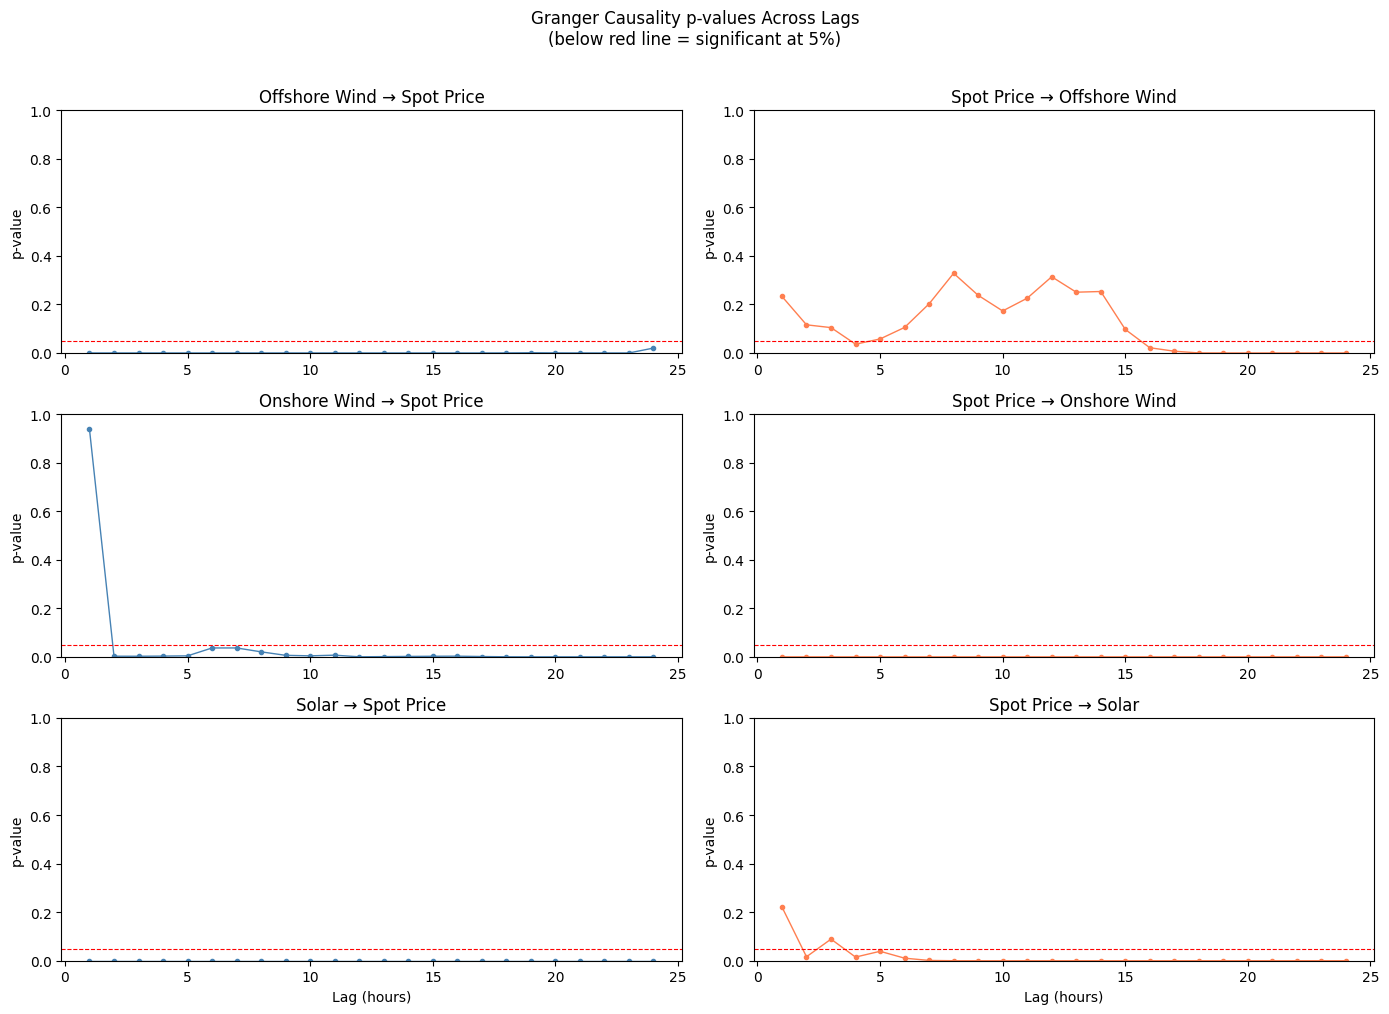

In [6]:
#P-values on lag
# Plotting p-values across lags shows not just WHETHER causality exists
# but at WHICH time horizons it is strongest.
# The red dashed line is the 0.05 significance threshold.

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
pairs = [
    (results_offshore,     results_rev_offshore, "Offshore Wind"),
    (results_onshore,      results_rev_onshore,  "Onshore Wind"),
    (results_solar,        results_rev_solar,    "Solar"),
]

for row, (fwd, rev, label) in enumerate(pairs):
    axes[row][0].plot(fwd["lag"], fwd["p_value"], marker="o", markersize=3, linewidth=1, color="steelblue")
    axes[row][0].axhline(0.05, color="red", linestyle="--", linewidth=0.8)
    axes[row][0].set_title(f"{label} → Spot Price")
    axes[row][0].set_ylabel("p-value")
    axes[row][0].set_ylim(0, 1)

    axes[row][1].plot(rev["lag"], rev["p_value"], marker="o", markersize=3, linewidth=1, color="coral")
    axes[row][1].axhline(0.05, color="red", linestyle="--", linewidth=0.8)
    axes[row][1].set_title(f"Spot Price → {label}")
    axes[row][1].set_ylabel("p-value")
    axes[row][1].set_ylim(0, 1)

for ax in axes[-1]:
    ax.set_xlabel("Lag (hours)")

plt.suptitle("Granger Causality p-values Across Lags\n(below red line = significant at 5%)", y=1.01)
plt.tight_layout()
plt.show()

In [7]:
#VAR-model
# VAR (Vector Autoregression) models all series jointly —
# each variable is regressed on its own past values AND
# the past values of all other variables simultaneously.
#
# This gives us a richer picture than pairwise Granger tests
# and is the foundation for impulse response analysis below.

var_data = data[["SpotPriceEUR_diff", "OffshoreWind_diff", "OnshoreWind_diff", "Solar_diff"]].dropna()

# Select optimal lag order automatically using AIC
model    = VAR(var_data)
lag_selection = model.select_order(maxlags=24)
print(lag_selection.summary())

optimal_lag = lag_selection.aic
print(f"\nOptimal lag by AIC: {optimal_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        36.04       36.05   4.472e+15       36.04
1        34.73       34.78   1.210e+15       34.75
2        34.61       34.70   1.071e+15       34.64
3        34.59       34.72   1.047e+15       34.64
4        34.56       34.74   1.019e+15       34.62
5        34.54       34.76   1.003e+15       34.62
6        34.49       34.76   9.551e+14       34.59
7        34.43       34.74   8.960e+14       34.54
8        34.37       34.72   8.442e+14       34.50
9        34.33       34.73   8.135e+14       34.48
10       34.28       34.71   7.712e+14       34.44
11       34.24       34.72   7.418e+14       34.41
12       34.18       34.70   6.986e+14       34.37
13       34.14       34.70   6.681e+14       34.34
14       34.09       34.69   6.377e+14       34.31
15       34.05       34.70   6.127e+14       34.29
16       34.03       34.72   5.

In [8]:
# Fit the VAR at the optimal lag
var_result = model.fit(optimal_lag)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 01, May, 2026
Time:                     01:53:52
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    34.6931
Nobs:                     2135.00    HQIC:                   34.0402
Log likelihood:          -47665.3    FPE:                4.16778e+14
AIC:                      33.6633    Det(Omega_mle):     3.48915e+14
--------------------------------------------------------------------
Results for equation SpotPriceEUR_diff
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                         0.066358         0.357587            0.186           0.853
L1.SpotPriceEUR_diff         -0.003131         0.021534           -0.145           0.884
L1.OffshoreWind_

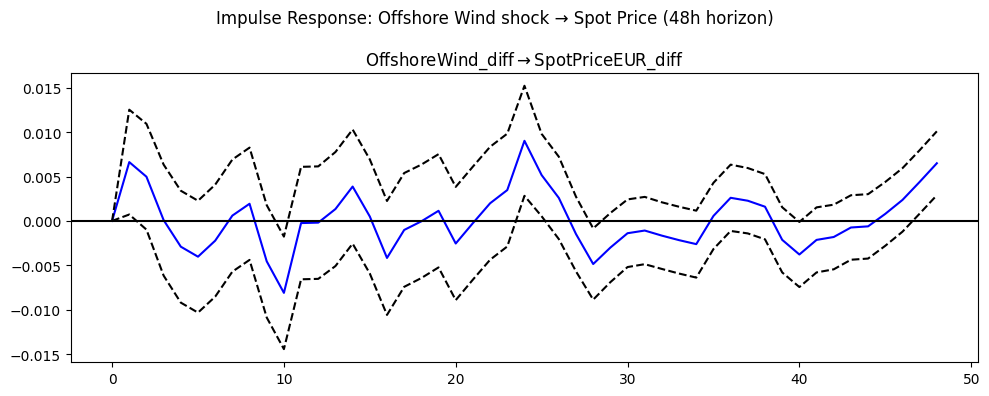

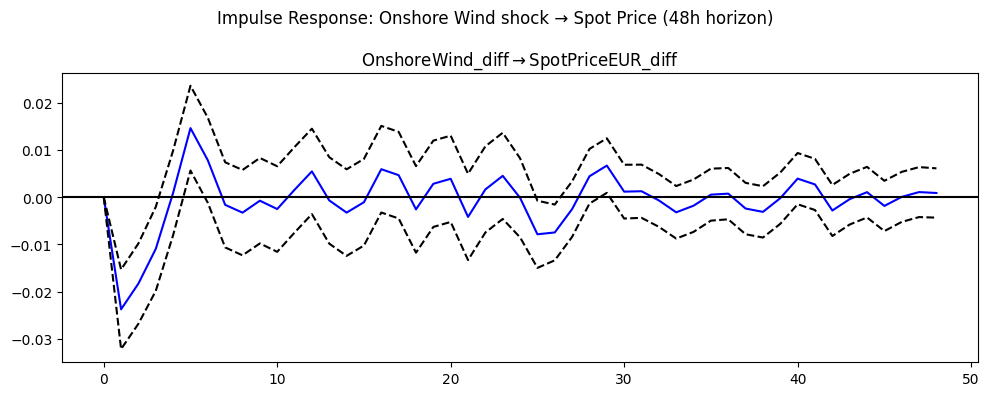

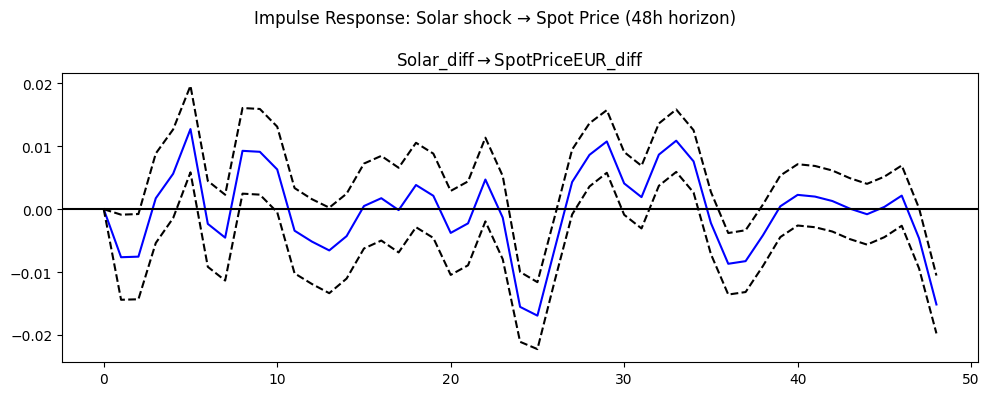

In [9]:
# Impulse Response Functions (IRF) answer:
# "If wind production suddenly spikes by one unit,
#  how does spot price respond over the next N hours?"
#
# This is more informative than a single correlation number
# because it shows the shape and duration of the response.

irf = var_result.irf(periods=48)

fig = irf.plot(impulse="OffshoreWind_diff", response="SpotPriceEUR_diff", figsize=(10, 4))
plt.suptitle("Impulse Response: Offshore Wind shock → Spot Price (48h horizon)")
plt.tight_layout()
plt.show()

fig = irf.plot(impulse="OnshoreWind_diff", response="SpotPriceEUR_diff", figsize=(10, 4))
plt.suptitle("Impulse Response: Onshore Wind shock → Spot Price (48h horizon)")
plt.tight_layout()
plt.show()

fig = irf.plot(impulse="Solar_diff", response="SpotPriceEUR_diff", figsize=(10, 4))
plt.suptitle("Impulse Response: Solar shock → Spot Price (48h horizon)")
plt.tight_layout()
plt.show()

In [10]:
# Summarise the full analytical journey in one table.
# This is what goes in the README and any presentation.

def first_sig_lag(df):
    sig = df[df["p_value"] < 0.05]
    return int(sig["lag"].min()) if not sig.empty else None

def min_p(df):
    return df["p_value"].min()

summary = pd.DataFrame({
    "Variable": ["Offshore Wind", "Onshore Wind", "Solar"],
    "Wind→Price: first sig. lag":  [
        first_sig_lag(results_offshore),
        first_sig_lag(results_onshore),
        first_sig_lag(results_solar)
    ],
    "Wind→Price: min p-value": [
        min_p(results_offshore),
        min_p(results_onshore),
        min_p(results_solar)
    ],
    "Price→Wind: first sig. lag": [
        first_sig_lag(results_rev_offshore),
        first_sig_lag(results_rev_onshore),
        first_sig_lag(results_rev_solar)
    ],
    "Price→Wind: min p-value": [
        min_p(results_rev_offshore),
        min_p(results_rev_onshore),
        min_p(results_rev_solar)
    ],
})

print(summary.to_string(index=False))
print()
print("Interpretation reminder:")
print("  Granger causality = predictive precedence, not physical causation.")
print("  Bidirectional significance suggests feedback loop, not clean causality.")

     Variable  Wind→Price: first sig. lag  Wind→Price: min p-value  Price→Wind: first sig. lag  Price→Wind: min p-value
Offshore Wind                           1                   0.0000                           4                   0.0000
 Onshore Wind                           2                   0.0000                           1                   0.0000
        Solar                           1                   0.0000                           2                   0.0000

Interpretation reminder:
  Granger causality = predictive precedence, not physical causation.
  Bidirectional significance suggests feedback loop, not clean causality.


Offshore Wind — causes price from lag 1 (immediate next hour), but price also causes offshore wind from lag 4. The wind → price direction is cleaner and stronger across all 24 lags. The reverse direction only becomes significant from lag 16 onward, suggesting the feedback is slow — possibly reflecting day-ahead market scheduling where yesterday's prices influence tomorrow's production decisions.
Onshore Wind — the most symmetric result. Price → onshore wind is significant from lag 1, same as wind → price. This tight bidirectionality suggests onshore producers are actively responding to price signals, possibly curtailing or ramping production based on market conditions.
Solar — wind → price significant from lag 1, price → solar from lag 2. Solar is the most physically constrained — it can't respond to prices the way wind can because you can't make the sun shine harder. The price → solar reverse causality likely reflects curtailment decisions or self-consumption switching rather than production responses.

#Conclusion
1. Raw correlations suggested wind suppresses price
2. After differencing, offshore wind's correlation nearly vanished
3. Granger tests confirmed bidirectional causality throughout —
   not a clean wind → price story but a feedback system
4. The VAR model revealed offshore wind has a counterintuitive
   positive coefficient, suggesting confounding by weather
5. Conclusion: correlation overstated the relationship,
   and even Granger causality has limits when confounders exist